# CIFAR10 e MNIST CNN: Ablação
Nesta versão do notebook, realizamos uma ablação do modelo CNN, removendo componentes e comparando o desempenho. O objetivo é entender a importância de cada componente da arquitetura para a tarefa de classificação.

**Componente em análise**: BatchNormalization
Você pode mudar os flags na classe para estudar diferentes componentes: `use_batch_norm` e `use_max_pool`


In [30]:
from pathlib import Path
import json
import time

import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms

from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

from sklearn.model_selection import KFold
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random
from tqdm import tqdm


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda


In [55]:
DATA_ROOT = Path("data")
OUTPUT_JSON = Path("../results") / "ablacao_batchnorm_metrics.json"
NUM_WORKERS = 2

OUTPUT_JSON.parent.mkdir(parents=True, exist_ok=True)


### Classe do Modelo

In [ ]:
class CNN(nn.Module):  # Versão com controle de componentes para ablação
    def __init__(self, input_shape, block_configs, fc_sizes, dropout_rate, activation_func,
                 conv_kernel_size=3, conv_stride=1, conv_padding=1, pool_kernel_size=2, 
                 use_batch_norm=True, use_max_pool=True):
        """
        Args:
            use_batch_norm: Se True, adiciona BatchNorm após primeira conv de cada bloco
            use_max_pool: Se True, adiciona MaxPooling ao final de cada bloco
        """
        super(CNN, self).__init__()

        layers = []
        in_channels = input_shape[0]

        for num_convs, out_channels in block_configs:
            for i in range(num_convs):
                layers.append(nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=conv_kernel_size,
                    stride=conv_stride,
                    padding=conv_padding
                ))

                if i == 0 and use_batch_norm:  # BatchNorm apenas na primeira conv de cada bloco
                    layers.append(nn.BatchNorm2d(out_channels))

                layers.append(activation_func)
                in_channels = out_channels

            if use_max_pool:  # MaxPooling ao final de cada bloco
                layers.append(nn.MaxPool2d(kernel_size=pool_kernel_size))
            
            layers.append(nn.Dropout2d(dropout_rate))

        self.features = nn.Sequential(*layers)

        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            try:
                dummy_output = self.features(dummy_input)
                flattened_size = dummy_output.numel()
            except RuntimeError as e:
                raise ValueError(f"As configurações encolheram a dimensão espacial a zero ou menos. Erro: {e}")

        fc_layers = []
        in_f = flattened_size
        for h_size in fc_sizes:
            fc_layers.append(nn.Linear(in_f, h_size))
            fc_layers.append(activation_func)
            fc_layers.append(nn.Dropout(dropout_rate))
            in_f = h_size

        fc_layers.append(nn.Linear(in_f, 10))
        self.classifier = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


### Carregamento de Dados

In [ ]:
cifar_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

mnist_transform = transforms.Compose(
    [transforms.Grayscale(num_output_channels=3),
     transforms.Resize((32, 32)),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Dataset CIFAR10

c10_train_dataset = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=True,
                                        download=True, transform=cifar_transform)
c10_test_dataset = torchvision.datasets.CIFAR10(root=str(DATA_ROOT), train=False,
                                       download=True, transform=cifar_transform)
c10_class_names = list(c10_train_dataset.classes)


# Dataset MNIST

mnist_train_dataset = torchvision.datasets.MNIST(root=str(DATA_ROOT), train=True,
                                        download=True, transform=mnist_transform)
mnist_test_dataset = torchvision.datasets.MNIST(root=str(DATA_ROOT), train=False,
                                       download=True, transform=mnist_transform)
mnist_class_names = [str(i) for i in range(10)]

### Funções Auxiliares

In [24]:


def set_seeds(seed):
    """Define todas as seeds para reprodutibilidade"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [22]:
def _collect_predictions(model, dataloader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Inferencia"):
            images = images.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1).cpu().tolist()
            all_preds.extend(preds)
            all_targets.extend(targets.tolist())
    return {"preds": all_preds, "targets": all_targets}

def evaluate_dataset(model, dataloader, class_names, dataset_name):
    start_time = time.time()
    results = _collect_predictions(model, dataloader)
    eval_time = time.time() - start_time
    
    preds = results["preds"]
    targets = results["targets"]
    acc = accuracy_score(targets, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        targets, preds, average="weighted", zero_division=0
    )
    conf_matrix = confusion_matrix(targets, preds).tolist()
    return {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": conf_matrix,
        "class_names": class_names,
        "eval_time_seconds": eval_time,
    }


In [23]:
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, targets in tqdm(dataloader, desc="Treino", leave=False):
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
    return running_loss / total, correct / total

In [25]:
def train_model(model, train_loader, optimizer, criterion, epochs, label):
    history = {"loss": [], "acc": [], "training_time_seconds": None}
    start_time = time.time()
    
    for epoch in range(epochs):
        loss, acc = train_one_epoch(model, train_loader, optimizer, criterion)
        history["loss"].append(loss)
        history["acc"].append(acc)
        if epoch == 0 or (epoch + 1) % 10 == 0 or (epoch + 1) == epochs:
            print(f"{label} - epoch {epoch + 1}/{epochs} - loss: {loss:.4f} - acc: {acc:.4f}")
    
    training_time = time.time() - start_time
    history["training_time_seconds"] = training_time
    return history


In [ ]:
def build_cnn_ablation_from_params(params, input_shape, use_batch_norm=True, use_max_pool=True):
    """Constrói CNN com opção de ativar/desativar componentes para ablação"""
    block_configs = params["arch_style"]
    fc_sizes = [params[f"fc_size_l{i}"] for i in range(params["n_fc_layers"])]
    activation = params["activation"]
    return CNN(
        input_shape=input_shape,
        block_configs=block_configs,
        fc_sizes=fc_sizes,
        dropout_rate=params["dropout"],
        activation_func=activation,
        conv_kernel_size=params["conv_kernel_size"],
        use_batch_norm=use_batch_norm,
        use_max_pool=use_max_pool,
    )


def build_adam_optimizer(model: nn.Module, lr: float, weight_decay: float):
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


## Avaliação

In [ ]:
cnn_params = {
    "input_shape": (3, 32, 32),
    "arch_style": [(2, 32), (2, 64), (2, 128)],
    "n_fc_layers": 1,
    "fc_size_l0": 2048,
    "conv_kernel_size": 3,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "dropout": 0.2,
    "batch_size": 32,
    "epochs": 50,
    "optimizer": "adam",
    "criterion": nn.CrossEntropyLoss(),
    "activation": nn.ReLU(),
}

In [28]:


epochs = cnn_params["epochs"]
criterion = cnn_params["criterion"]
input_shape = cnn_params["input_shape"]
batch_size = cnn_params["batch_size"]

c10_train_loader = DataLoader(
    c10_train_dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS
 )
c10_test_loader = DataLoader(
    c10_test_dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS
 )
mnist_train_loader = DataLoader(
    mnist_train_dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS
 )
mnist_test_loader = DataLoader(
    mnist_test_dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS
 )

### Treino para Ablação
Treinar múltiplas vezes com diferentes seeds aleatórios para comparar o impacto de remover BatchNormalization.
(Para mudar o componente: modifique os parâmetros `use_batch_norm` e `use_max_pool` nas chamadas de `build_cnn_ablacao_from_params`)


In [ ]:
seeds = [42, 123, 456]
ablation_results = {}

for dataset_name, train_loader, test_loader, class_names in [
    ("CIFAR-10", c10_train_loader, c10_test_loader, c10_class_names),
    ("MNIST", mnist_train_loader, mnist_test_loader, mnist_class_names)
]:
    ablation_results[dataset_name] = {"com_bn": {}, "sem_bn": {}}
    
    for seed in seeds:
        set_seeds(seed)
        model_bn = build_cnn_ablation_from_params(cnn_params, input_shape, use_batch_norm=True, use_max_pool=True).to(device)
        optimizer_bn = build_adam_optimizer(model_bn, cnn_params["lr"], cnn_params["weight_decay"])
        
        print(f"\n{dataset_name} - Seed {seed} - WITH BatchNorm")
        hist_bn = train_model(model_bn, train_loader, optimizer_bn, criterion, epochs, f"{dataset_name} [BN]")
        metrics_bn = evaluate_dataset(model_bn, test_loader, class_names, dataset_name)
        
        set_seeds(seed)
        model_no_bn = build_cnn_ablation_from_params(cnn_params, input_shape, use_batch_norm=False, use_max_pool=True).to(device)
        optimizer_no_bn = build_adam_optimizer(model_no_bn, cnn_params["lr"], cnn_params["weight_decay"])
        
        print(f"{dataset_name} - Seed {seed} - WITHOUT BatchNorm")
        hist_no_bn = train_model(model_no_bn, train_loader, optimizer_no_bn, criterion, epochs, f"{dataset_name} [NoBN]")
        metrics_no_bn = evaluate_dataset(model_no_bn, test_loader, class_names, dataset_name)
        
        ablation_results[dataset_name]["com_bn"][seed] = {
            "history": hist_bn,
            "metrics": metrics_bn
        }
        ablation_results[dataset_name]["sem_bn"][seed] = {
            "history": hist_no_bn,
            "metrics": metrics_no_bn
        }



CIFAR-10 - Seed 42 - WITH BatchNorm


CIFAR-10 [BN] - epoch 1/50 - loss: 1.5217 - acc: 0.4441


CIFAR-10 [BN] - epoch 10/50 - loss: 0.4881 - acc: 0.8300


CIFAR-10 [BN] - epoch 20/50 - loss: 0.2030 - acc: 0.9294


CIFAR-10 [BN] - epoch 30/50 - loss: 0.1049 - acc: 0.9644


...

MNIST [NoBN] - epoch 20/50 - loss: 0.0106 - acc: 0.9966


MNIST [NoBN] - epoch 30/50 - loss: 0.0073 - acc: 0.9977


MNIST [NoBN] - epoch 40/50 - loss: 0.0068 - acc: 0.9977


MNIST [NoBN] - epoch 50/50 - loss: 0.0056 - acc: 0.9982


Inferencia: 100%|██████████| 313/313 [00:06<00:00, 49.07it/s] 


### Análise Estatística

In [52]:
results_summary = {}


for dataset_name in ablation_results:
    
    acc_com_bn = [ablation_results[dataset_name]["com_bn"][s]["metrics"]["accuracy"] for s in seeds]
    acc_sem_bn = [ablation_results[dataset_name]["sem_bn"][s]["metrics"]["accuracy"] for s in seeds]

    f1_com_bn = [ablation_results[dataset_name]["com_bn"][s]["metrics"]["f1_score"] for s in seeds]
    f1_sem_bn = [ablation_results[dataset_name]["sem_bn"][s]["metrics"]["f1_score"] for s in seeds]

    recall_com_bn = [ablation_results[dataset_name]["com_bn"][s]["metrics"]["recall"] for s in seeds]
    recall_sem_bn = [ablation_results[dataset_name]["sem_bn"][s]["metrics"]["recall"] for s in seeds]

    precision_com_bn = [ablation_results[dataset_name]["com_bn"][s]["metrics"]["precision"] for s in seeds]
    precision_sem_bn = [ablation_results[dataset_name]["sem_bn"][s]["metrics"]["precision"] for s in seeds]
    
    train_time_com_bn = [ablation_results[dataset_name]["com_bn"][s]["history"]["training_time_seconds"] for s in seeds]
    train_time_sem_bn = [ablation_results[dataset_name]["sem_bn"][s]["history"]["training_time_seconds"] for s in seeds]
    
    eval_time_com_bn = [ablation_results[dataset_name]["com_bn"][s]["metrics"]["eval_time_seconds"] for s in seeds]
    eval_time_sem_bn = [ablation_results[dataset_name]["sem_bn"][s]["metrics"]["eval_time_seconds"] for s in seeds]

    results_summary[dataset_name] = {
        "com_bn": {
            "accuracy": {
                "mean": np.mean(acc_com_bn),
                "std": np.std(acc_com_bn),
                "values": acc_com_bn
            },
            "f1_score": {
                "mean": np.mean(f1_com_bn),
                "std": np.std(f1_com_bn),
                "values": f1_com_bn
            },
            "recall": {
                "mean": np.mean(recall_com_bn),
                "std": np.std(recall_com_bn),
                "values": recall_com_bn
            },
            "precision": {
                "mean": np.mean(precision_com_bn),
                "std": np.std(precision_com_bn),
                "values": precision_com_bn
            },
            "train_time": {
                "mean": np.mean(train_time_com_bn),
                "std": np.std(train_time_com_bn),
                "values": train_time_com_bn
            },
            "eval_time": {
                "mean": np.mean(eval_time_com_bn),
                "std": np.std(eval_time_com_bn),
                "values": eval_time_com_bn
            }
        },
        "sem_bn": {
            "accuracy": {
                "mean": np.mean(acc_sem_bn),
                "std": np.std(acc_sem_bn),
                "values": acc_sem_bn
            },
            "f1_score": {
                "mean": np.mean(f1_sem_bn),
                "std": np.std(f1_sem_bn),
                "values": f1_sem_bn
            },
            "recall": {
                "mean": np.mean(recall_sem_bn),
                "std": np.std(recall_sem_bn),
                "values": recall_sem_bn
            },
            "precision": {
                "mean": np.mean(precision_sem_bn),
                "std": np.std(precision_sem_bn),
                "values": precision_sem_bn
            },
            "train_time": {
                "mean": np.mean(train_time_sem_bn),
                "std": np.std(train_time_sem_bn),
                "values": train_time_sem_bn
            },
            "eval_time": {
                "mean": np.mean(eval_time_sem_bn),
                "std": np.std(eval_time_sem_bn),
                "values": eval_time_sem_bn
            }
        },
        "accuracy_difference": np.mean(acc_com_bn) - np.mean(acc_sem_bn),
        "train_time_difference": np.mean(train_time_com_bn) - np.mean(train_time_sem_bn),
        "eval_time_difference": np.mean(eval_time_com_bn) - np.mean(eval_time_sem_bn),
    }
    
    print(f"{dataset_name}:")
    print(f"Acurácia:")
    print(f"  Com BatchNorm:    {results_summary[dataset_name]['com_bn']['accuracy']['mean']:.4f} ± {results_summary[dataset_name]['com_bn']['accuracy']['std']:.4f}")
    print(f"  Sem BatchNorm:  {results_summary[dataset_name]['sem_bn']['accuracy']['mean']:.4f} ± {results_summary[dataset_name]['sem_bn']['accuracy']['std']:.4f}")
    print(f"  Diferença:          {results_summary[dataset_name]['accuracy_difference']:+.4f}")
    print(f"\nTempo de Treinamento (s):")
    print(f"  Com BatchNorm:    {results_summary[dataset_name]['com_bn']['train_time']['mean']:.2f} ± {results_summary[dataset_name]['com_bn']['train_time']['std']:.2f}")
    print(f"  Sem BatchNorm:  {results_summary[dataset_name]['sem_bn']['train_time']['mean']:.2f} ± {results_summary[dataset_name]['sem_bn']['train_time']['std']:.2f}")
    print(f"  Diferença:          {results_summary[dataset_name]['train_time_difference']:+.2f}s ({(results_summary[dataset_name]['train_time_difference']/results_summary[dataset_name]['com_bn']['train_time']['mean']*100):+.1f}%)")

CIFAR-10:
Acurácia:
  Com BatchNorm:    0.8246 ± 0.0009
  Sem BatchNorm:  0.7598 ± 0.0028
  Diferença:          +0.0648

Tempo de Treinamento (s):
  Com BatchNorm:    1153.68 ± 62.00
  Sem BatchNorm:  1087.55 ± 50.82
  Diferença:          +66.12s (+5.7%)
MNIST:
Acurácia:
  Com BatchNorm:    0.9946 ± 0.0004
  Sem BatchNorm:  0.9934 ± 0.0006
  Diferença:          +0.0012

Tempo de Treinamento (s):
  Com BatchNorm:    1027.06 ± 20.12
  Sem BatchNorm:  962.45 ± 27.23
  Diferença:          +64.61s (+6.3%)


### Visualizações

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_41792\3659316932.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Com\nBatchNorm", "Sem\nBatchNorm"],
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_41792\3659316932.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Com\nBatchNorm", "Sem\nBatchNorm"],
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_41792\3659316932.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Com\nBatchNorm", "Sem\nBatchNorm"],
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_41792\3659316932.py:9: Matplotl

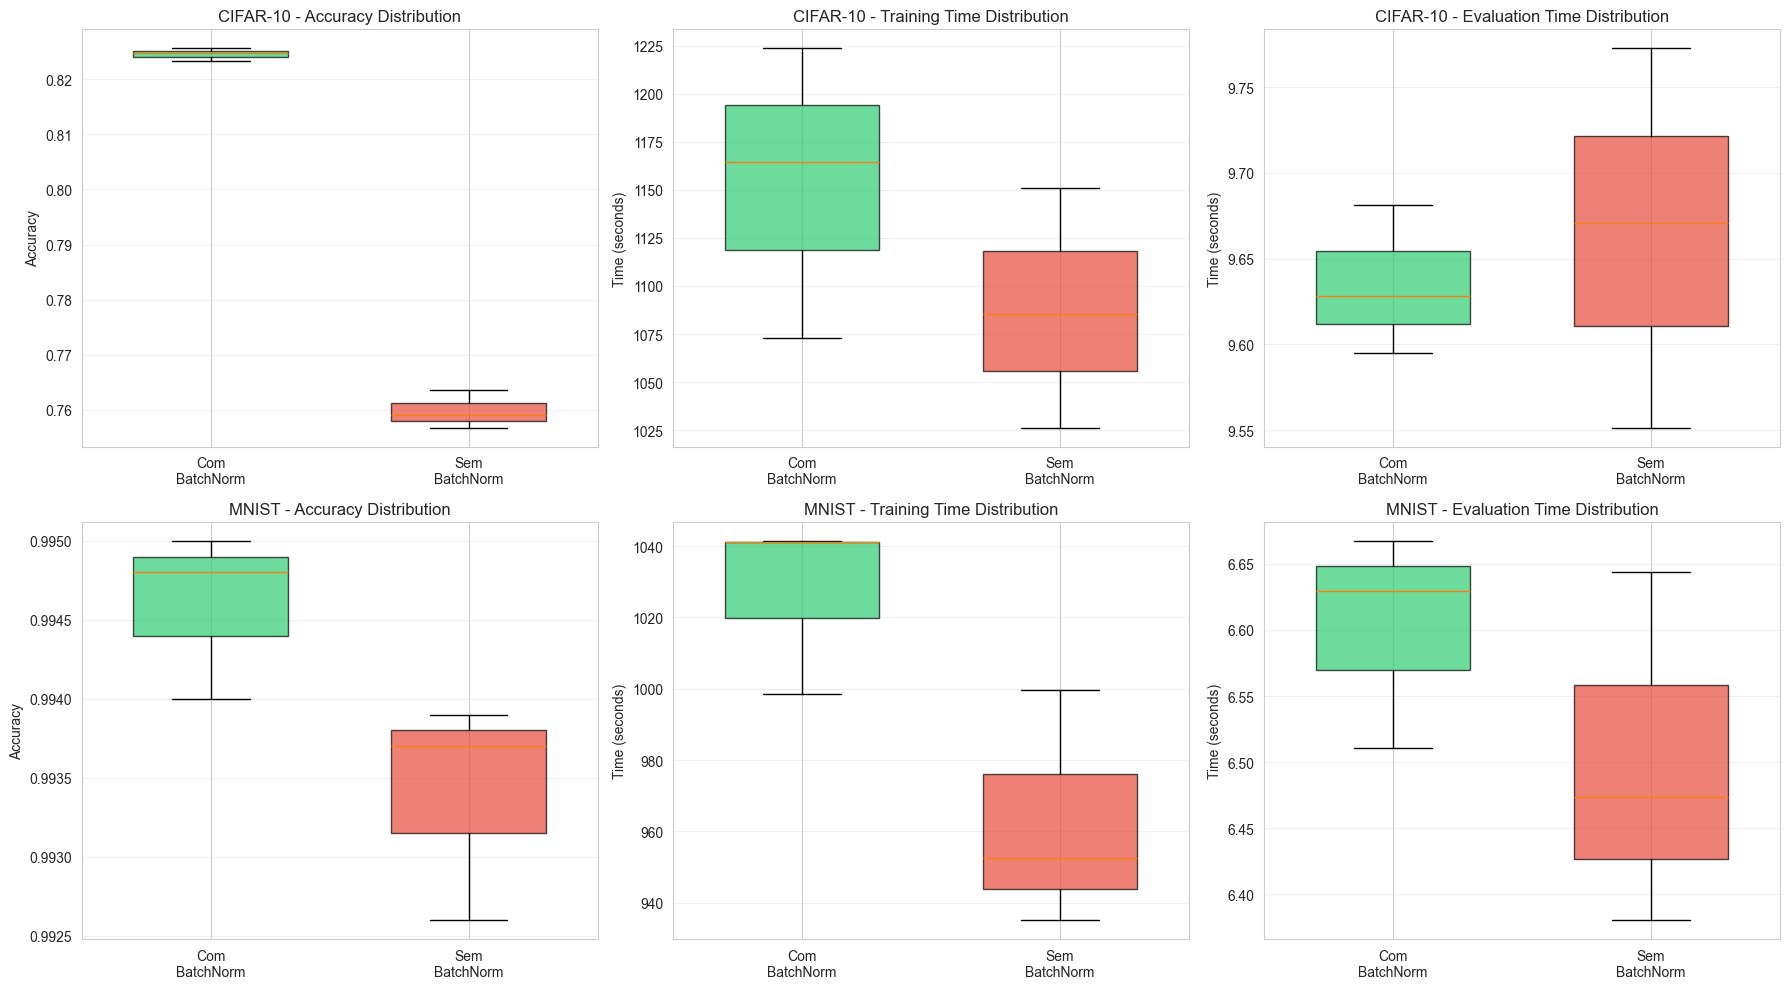

In [51]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, dataset_name in enumerate(["CIFAR-10", "MNIST"]):
    # Acurácia
    ax = axes[idx, 0]
    data = [results_summary[dataset_name]["com_bn"]["accuracy"]["values"],
            results_summary[dataset_name]["sem_bn"]["accuracy"]["values"]]
    bp = ax.boxplot(data, labels=["Com\nBatchNorm", "Sem\nBatchNorm"],
                    patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{dataset_name} - Accuracy Distribution')
    ax.grid(axis='y', alpha=0.3)
    
    # Tempo de Treinamento
    ax = axes[idx, 1]
    data = [results_summary[dataset_name]["com_bn"]["train_time"]["values"],
            results_summary[dataset_name]["sem_bn"]["train_time"]["values"]]
    bp = ax.boxplot(data, labels=["Com\nBatchNorm", "Sem\nBatchNorm"],
                    patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Time (seconds)')
    ax.set_title(f'{dataset_name} - Training Time Distribution')
    ax.grid(axis='y', alpha=0.3)
    
    # Tempo de Avaliação
    ax = axes[idx, 2]
    data = [results_summary[dataset_name]["com_bn"]["eval_time"]["values"],
            results_summary[dataset_name]["sem_bn"]["eval_time"]["values"]]
    bp = ax.boxplot(data, labels=["Com\nBatchNorm", "Sem\nBatchNorm"],
                    patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Time (seconds)')
    ax.set_title(f'{dataset_name} - Evaluation Time Distribution')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/ablation_with_times.png", dpi=150, bbox_inches='tight')
plt.show()


### Exportar Resultados (com Timings)


In [56]:
export_data = {}
for dataset_name in ablation_results:
    export_data[dataset_name] = {
        "com_bn": {
            "statistics": {
                "accuracy": {
                    "mean": float(results_summary[dataset_name]["com_bn"]["accuracy"]["mean"]),
                    "std": float(results_summary[dataset_name]["com_bn"]["accuracy"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["com_bn"]["accuracy"]["values"]]
                },
                "f1_score": {
                    "mean": float(results_summary[dataset_name]["com_bn"]["f1_score"]["mean"]),
                    "std": float(results_summary[dataset_name]["com_bn"]["f1_score"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["com_bn"]["f1_score"]["values"]]
                },
                "recall": {
                    "mean": float(results_summary[dataset_name]["com_bn"]["recall"]["mean"]),
                    "std": float(results_summary[dataset_name]["com_bn"]["recall"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["com_bn"]["recall"]["values"]]
                },
                "precision": {
                    "mean": float(results_summary[dataset_name]["com_bn"]["precision"]["mean"]),
                    "std": float(results_summary[dataset_name]["com_bn"]["precision"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["com_bn"]["precision"]["values"]]
                },
                "train_time_seconds": {
                    "mean": float(results_summary[dataset_name]["com_bn"]["train_time"]["mean"]),
                    "std": float(results_summary[dataset_name]["com_bn"]["train_time"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["com_bn"]["train_time"]["values"]]
                },
                "eval_time_seconds": {
                    "mean": float(results_summary[dataset_name]["com_bn"]["eval_time"]["mean"]),
                    "std": float(results_summary[dataset_name]["com_bn"]["eval_time"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["com_bn"]["eval_time"]["values"]]
                }
            },
            "details": {
                str(seed): {
                    "history": ablation_results[dataset_name]["com_bn"][seed]["history"],
                    "metrics": ablation_results[dataset_name]["com_bn"][seed]["metrics"]
                } for seed in seeds
            }
        },
        "sem_bn": {
            "statistics": {
                "accuracy": {
                    "mean": float(results_summary[dataset_name]["sem_bn"]["accuracy"]["mean"]),
                    "std": float(results_summary[dataset_name]["sem_bn"]["accuracy"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["sem_bn"]["accuracy"]["values"]]
                },
                "f1_score": {
                    "mean": float(results_summary[dataset_name]["sem_bn"]["f1_score"]["mean"]),
                    "std": float(results_summary[dataset_name]["sem_bn"]["f1_score"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["sem_bn"]["f1_score"]["values"]]
                },
                "recall": {
                    "mean": float(results_summary[dataset_name]["sem_bn"]["recall"]["mean"]),
                    "std": float(results_summary[dataset_name]["sem_bn"]["recall"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["sem_bn"]["recall"]["values"]]
                },
                "precision": {
                    "mean": float(results_summary[dataset_name]["sem_bn"]["precision"]["mean"]),
                    "std": float(results_summary[dataset_name]["sem_bn"]["precision"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["sem_bn"]["precision"]["values"]]
                },
                "train_time_seconds": {
                    "mean": float(results_summary[dataset_name]["sem_bn"]["train_time"]["mean"]),
                    "std": float(results_summary[dataset_name]["sem_bn"]["train_time"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["sem_bn"]["train_time"]["values"]]
                },
                "eval_time_seconds": {
                    "mean": float(results_summary[dataset_name]["sem_bn"]["eval_time"]["mean"]),
                    "std": float(results_summary[dataset_name]["sem_bn"]["eval_time"]["std"]),
                    "values": [float(v) for v in results_summary[dataset_name]["sem_bn"]["eval_time"]["values"]]
                }
            },
            "details": {
                str(seed): {
                    "history": ablation_results[dataset_name]["sem_bn"][seed]["history"],
                    "metrics": ablation_results[dataset_name]["sem_bn"][seed]["metrics"]
                } for seed in seeds
            }
        },
        "differences": {
            "accuracy": float(results_summary[dataset_name]["accuracy_difference"]),
            "train_time_seconds": float(results_summary[dataset_name]["train_time_difference"]),
            "train_time_percentage": float(results_summary[dataset_name]["train_time_difference"]/results_summary[dataset_name]["com_bn"]["train_time"]["mean"]*100),
            "eval_time_seconds": float(results_summary[dataset_name]["eval_time_difference"]),
            "eval_time_percentage": float(results_summary[dataset_name]["eval_time_difference"]/results_summary[dataset_name]["com_bn"]["eval_time"]["mean"]*100),
        }
    }

with open(OUTPUT_JSON, "w") as f:
    json.dump(export_data, f, indent=4)

print(f"\nResults saved to: {OUTPUT_JSON}")



Results saved to: ..\results\ablacao_batchnorm_metrics.json
